# 02 Model Estimation: In-Sample ARCH-Family Models

This notebook estimates baseline ARCH-family volatility models for daily Bitcoin log returns using the training sample only.

Lower AIC/BIC values indicate better in-sample fit after accounting for model complexity. Residual diagnostics are used to check whether remaining serial dependence in standardized residuals or squared standardized residuals remains after fitting the volatility model.

The mean equation is kept constant in this baseline notebook because the Ljung-Box tests on raw returns did not strongly suggest serial correlation.

**TODO:** AR or ARMA mean equations can be considered later as robustness checks.

## 1. Imports and path setup

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import arch
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)

arch version: 8.0.0


In [2]:
# Configuration
TEST_SIZE = 0.20
LJUNG_BOX_LAGS = [10, 20, 30]
ARCH_LM_LAGS = 10

# Returns are already measured in percentage points, so automatic rescaling is not needed here.
RESCALE_RETURNS = False


def find_project_root(start: Path | None = None) -> Path:
    """Find the project root from either the notebook folder or the repository root."""
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data_clean").exists() and (candidate / "data_raw").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data_clean/ and data_raw/.")


PROJECT_ROOT = find_project_root()
DATA_CLEAN_PATH = PROJECT_ROOT / "data_clean" / "btc_daily_returns.csv"
DATA_RAW_PATH = PROJECT_ROOT / "data_raw" / "btc_yfinance.csv"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "output" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "output" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

C:\Users\matth\OneDrive\Bureaublad\school\VU\Year 3\Thesis\project


## 2. Load Bitcoin return data

The notebook first tries to load `data_clean/btc_daily_returns.csv`. If that file is unavailable, it reconstructs prices and log returns from `data_raw/btc_yfinance.csv`. The raw-data helper handles common yfinance column formats, including MultiIndex-style CSV headers.

In [3]:
def _clean_index_to_datetime(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame.index = pd.to_datetime(frame.index, errors="coerce")
    frame = frame.loc[frame.index.notna()]
    frame.index.name = "Date"
    return frame.sort_index()


def _select_close_price(raw: pd.DataFrame) -> pd.Series:
    """Select the Close column from a yfinance-style DataFrame."""
    if isinstance(raw.columns, pd.MultiIndex):
        close_columns = [col for col in raw.columns if str(col[0]).lower() == "close"]
        if not close_columns:
            close_columns = [
                col for col in raw.columns
                if any("close" in str(part).lower() for part in col)
            ]
    else:
        close_columns = [col for col in raw.columns if str(col).lower() == "close"]
        if not close_columns:
            close_columns = [col for col in raw.columns if "close" in str(col).lower()]

    if not close_columns:
        raise KeyError("No Close column found in the raw yfinance data.")

    price = pd.to_numeric(raw[close_columns[0]], errors="coerce")
    return price.dropna().rename("price")


def load_clean_returns(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path)

    date_candidates = [col for col in data.columns if str(col).lower() in {"date", "datetime"}]
    date_column = date_candidates[0] if date_candidates else data.columns[0]

    data[date_column] = pd.to_datetime(data[date_column], errors="coerce")
    data = data.loc[data[date_column].notna()].set_index(date_column)
    data.index.name = "Date"
    data = data.sort_index()

    if "log_return" not in data.columns:
        if "price" not in data.columns:
            raise KeyError("Clean data must contain log_return or price.")
        data["price"] = pd.to_numeric(data["price"], errors="coerce")
        data["log_return"] = 100 * np.log(data["price"] / data["price"].shift(1))

    if "price" in data.columns:
        data["price"] = pd.to_numeric(data["price"], errors="coerce")
    data["log_return"] = pd.to_numeric(data["log_return"], errors="coerce")

    return data[[col for col in ["price", "log_return"] if col in data.columns]].dropna()


def load_raw_yfinance(path: Path) -> pd.DataFrame:
    read_attempts = [
        {"header": [0, 1], "index_col": 0, "parse_dates": True},
        {"header": [0, 1, 2], "index_col": 0, "parse_dates": True},
        {"header": 0, "index_col": 0, "parse_dates": True},
    ]
    errors = []

    for kwargs in read_attempts:
        try:
            raw = pd.read_csv(path, **kwargs)
            raw = _clean_index_to_datetime(raw)
            price = _select_close_price(raw)
            returns = (100 * np.log(price / price.shift(1))).dropna().rename("log_return")
            return pd.concat([price, returns], axis=1).dropna()
        except Exception as exc:
            errors.append(f"{kwargs}: {type(exc).__name__}: {exc}")

    raise ValueError("Could not read raw yfinance data. Attempts: " + " | ".join(errors))


def load_return_data(clean_path: Path, raw_path: Path) -> tuple[pd.DataFrame, Path]:
    if clean_path.exists():
        return load_clean_returns(clean_path), clean_path
    if raw_path.exists():
        return load_raw_yfinance(raw_path), raw_path
    raise FileNotFoundError("Neither clean nor raw Bitcoin data file was found.")

In [4]:
df, data_source = load_return_data(DATA_CLEAN_PATH, DATA_RAW_PATH)
df = df.loc[~df.index.duplicated(keep="first")].sort_index()
returns = df["log_return"].dropna().astype(float)

print(f"Data source: {data_source.relative_to(PROJECT_ROOT)}")
print(f"Observations available: {len(returns)}")
display(df.head())
display(df.tail())

Data source: data_clean\btc_daily_returns.csv
Observations available: 3804


,price,log_return
Date,,
2016-01-02,433.437988,-0.206512
2016-01-03,430.010986,-0.793798
2016-01-04,433.091003,0.713712
2016-01-05,431.959991,-0.261490
2016-01-06,429.105011,-0.663130


,price,log_return
Date,,
2026-05-28,73536.554688,-1.092980
2026-05-29,73372.523438,-0.223310
2026-05-30,73754.835938,0.519704
2026-05-31,73579.687500,-0.237756
2026-06-01,71841.968750,-2.390017


## 3. Define train/test split

The split is chronological. The first 80% of observations are used for in-sample estimation in this notebook, while the last 20% are reserved for later out-of-sample forecasting.

In [5]:
if not 0 < TEST_SIZE < 1:
    raise ValueError("TEST_SIZE must be strictly between 0 and 1.")

split_idx = int(len(returns) * (1 - TEST_SIZE))
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]

split_summary = pd.DataFrame(
    {
        "sample": ["train", "test"],
        "start_date": [train_returns.index.min(), test_returns.index.min()],
        "end_date": [train_returns.index.max(), test_returns.index.max()],
        "nobs": [len(train_returns), len(test_returns)],
    }
)

split_summary

,sample,start_date,end_date,nobs
0,train,2016-01-02,2024-05-01,3043
1,test,2024-05-02,2026-06-01,761


## 4. Define model grid

The baseline volatility models are ARCH(1), ARCH(2), ARCH(3), GARCH(1,1), and EGARCH(1,1). The EGARCH specification includes one asymmetric term through `o=1`.

Distributions attempted here are those directly supported by the installed `arch` package: Normal, Student-t, Skewed Student-t, and GED.

**TODO:** Asymmetric Student-t and Asymmetric Exponential Power Distribution specifications are possible extensions, but they are not implemented here because they are not directly available in `arch_model` without custom distribution work.

In [6]:
VOLATILITY_SPECS = [
    {"model_name": "ARCH(1)", "volatility_model": "ARCH", "p": 1, "o": 0, "q": 0},
    {"model_name": "ARCH(2)", "volatility_model": "ARCH", "p": 2, "o": 0, "q": 0},
    {"model_name": "ARCH(3)", "volatility_model": "ARCH", "p": 3, "o": 0, "q": 0},
    {"model_name": "GARCH(1,1)", "volatility_model": "GARCH", "p": 1, "o": 0, "q": 1},
    {"model_name": "EGARCH(1,1)", "volatility_model": "EGARCH", "p": 1, "o": 1, "q": 1},
]

DISTRIBUTION_SPECS = [
    {"distribution": "Normal", "dist": "normal"},
    {"distribution": "Student-t", "dist": "t"},
    {"distribution": "Skewed Student-t", "dist": "skewt"},
    {"distribution": "GED", "dist": "ged"},
]

model_grid = pd.DataFrame(
    [
        {
            **vol_spec,
            **dist_spec,
            "fit_id": f"{vol_spec['model_name']} | {dist_spec['distribution']}",
        }
        for vol_spec in VOLATILITY_SPECS
        for dist_spec in DISTRIBUTION_SPECS
    ]
)

model_grid[["fit_id", "volatility_model", "p", "o", "q", "distribution"]]

,fit_id,volatility_model,p,o,q,distribution
0,ARCH(1) | Normal,ARCH,1,0,0,Normal
1,ARCH(1) | Student-t,ARCH,1,0,0,Student-t
2,ARCH(1) | Skewed Student-t,ARCH,1,0,0,Skewed Student-t
3,ARCH(1) | GED,ARCH,1,0,0,GED
4,ARCH(2) | Normal,ARCH,2,0,0,Normal
5,ARCH(2) | Student-t,ARCH,2,0,0,Student-t
6,ARCH(2) | Skewed Student-t,ARCH,2,0,0,Skewed Student-t
7,ARCH(2) | GED,ARCH,2,0,0,GED
8,ARCH(3) | Normal,ARCH,3,0,0,Normal
9,ARCH(3) | Student-t,ARCH,3,0,0,Student-t


## 5. Estimate ARCH-family models

In [7]:
BASE_FIT_COLUMNS = [
    "fit_id",
    "model_name",
    "volatility_model",
    "p",
    "o",
    "q",
    "distribution",
    "nobs",
    "loglikelihood",
    "AIC",
    "BIC",
    "convergence_flag",
    "convergence_success",
    "error_message",
]

PARAMETER_COLUMN_ORDER = [
    "mu",
    "omega",
    "alpha[1]",
    "alpha[2]",
    "alpha[3]",
    "gamma[1]",
    "beta[1]",
    "nu",
    "eta",
    "lambda",
]


def fit_arch_model(spec: pd.Series, y: pd.Series) -> tuple[dict, object | None]:
    row = {col: spec.get(col, np.nan) for col in BASE_FIT_COLUMNS}
    row.update({"nobs": np.nan, "loglikelihood": np.nan, "AIC": np.nan, "BIC": np.nan})
    row["convergence_flag"] = np.nan
    row["convergence_success"] = False
    row["error_message"] = ""

    try:
        model = arch_model(
            y,
            mean="Constant",
            vol=spec["volatility_model"],
            p=int(spec["p"]),
            o=int(spec["o"]),
            q=int(spec["q"]),
            dist=spec["dist"],
            rescale=RESCALE_RETURNS,
        )

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always")
            result = model.fit(disp="off", show_warning=False)

        convergence_flag = getattr(result, "convergence_flag", np.nan)
        optimization_result = getattr(result, "optimization_result", None)
        optimization_success = getattr(optimization_result, "success", convergence_flag == 0)
        optimization_message = getattr(optimization_result, "message", "")
        warning_message = "; ".join(str(w.message) for w in caught_warnings)

        row.update(
            {
                "nobs": int(result.nobs),
                "loglikelihood": float(result.loglikelihood),
                "AIC": float(result.aic),
                "BIC": float(result.bic),
                "convergence_flag": convergence_flag,
                "convergence_success": bool(optimization_success) and convergence_flag == 0,
                "error_message": warning_message,
            }
        )

        if not row["convergence_success"] and optimization_message:
            row["error_message"] = str(optimization_message)

        for parameter_name, parameter_value in result.params.items():
            row[parameter_name] = float(parameter_value)

        return row, result

    except Exception as exc:
        row["error_message"] = f"{type(exc).__name__}: {exc}"
        return row, None


def order_fit_summary_columns(summary: pd.DataFrame) -> pd.DataFrame:
    parameter_cols = [col for col in summary.columns if col not in BASE_FIT_COLUMNS]
    ordered_parameters = [col for col in PARAMETER_COLUMN_ORDER if col in parameter_cols]
    extra_parameters = sorted(col for col in parameter_cols if col not in ordered_parameters)
    ordered_cols = BASE_FIT_COLUMNS + ordered_parameters + extra_parameters
    return summary.reindex(columns=ordered_cols)

In [8]:
fit_rows = []
fitted_models = {}

for _, spec in model_grid.iterrows():
    fit_row, result = fit_arch_model(spec, train_returns)
    fit_rows.append(fit_row)

    if result is not None and fit_row["convergence_success"]:
        fitted_models[fit_row["fit_id"]] = result

model_fit_summary = order_fit_summary_columns(pd.DataFrame(fit_rows))
model_fit_summary_display = model_fit_summary.sort_values("BIC", na_position="last").reset_index(drop=True)

display(model_fit_summary_display.round(6))

,fit_id,model_name,volatility_model,p,o,q,distribution,nobs,loglikelihood,AIC,BIC,convergence_flag,convergence_success,error_message,mu,omega,alpha[1],alpha[2],alpha[3],gamma[1],beta[1],nu,eta,lambda
0,"EGARCH(1,1) | Student-t","EGARCH(1,1)",EGARCH,1,1,1,Student-t,3043,-7612.823186,15237.646372,15273.769967,0,True,,0.133964,0.083890,0.257478,NaN,NaN,0.038949,0.994434,2.525285,NaN,NaN
1,"EGARCH(1,1) | Skewed Student-t","EGARCH(1,1)",EGARCH,1,1,1,Skewed Student-t,3043,-7612.748418,15239.496836,15281.641030,0,True,,0.122923,0.084252,0.258278,NaN,NaN,0.038904,0.994415,NaN,2.523708,-0.008006
2,"EGARCH(1,1) | GED","EGARCH(1,1)",EGARCH,1,1,1,GED,3043,-7631.317908,15274.635817,15310.759411,0,True,,0.122448,0.079166,0.214866,NaN,NaN,0.006675,0.974048,1.010000,NaN,NaN
3,"GARCH(1,1) | Student-t","GARCH(1,1)",GARCH,1,0,1,Student-t,3043,-7642.516019,15295.032038,15325.135034,0,True,,0.145421,0.114531,0.094025,NaN,NaN,NaN,0.905975,3.217739,NaN,NaN
4,"GARCH(1,1) | GED","GARCH(1,1)",GARCH,1,0,1,GED,3043,-7642.898043,15295.796085,15325.899081,0,True,,0.124399,0.169915,0.104641,NaN,NaN,NaN,0.886469,1.010000,NaN,NaN
5,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",GARCH,1,0,1,Skewed Student-t,3043,-7642.503682,15297.007364,15333.130959,0,True,,0.141268,0.114755,0.094096,NaN,NaN,NaN,0.905904,NaN,3.218065,-0.003296
6,ARCH(3) | GED,ARCH(3),ARCH,3,0,0,GED,3043,-7750.920729,15513.841458,15549.965053,0,True,,0.146901,6.275528,0.248283,0.159282,0.127256,NaN,NaN,1.010000,NaN,NaN
7,ARCH(3) | Student-t,ARCH(3),ARCH,3,0,0,Student-t,3043,-7759.930547,15531.861094,15567.984689,0,True,,0.169866,9.766921,0.454538,0.294956,0.250506,NaN,NaN,2.556273,NaN,NaN
8,ARCH(3) | Skewed Student-t,ARCH(3),ARCH,3,0,0,Skewed Student-t,3043,-7759.927450,15533.854900,15575.999094,0,True,,0.172939,9.769607,0.454345,0.295047,0.250609,NaN,NaN,NaN,2.556110,0.001629
9,ARCH(2) | GED,ARCH(2),ARCH,2,0,0,GED,3043,-7770.340843,15550.681687,15580.784683,0,True,,0.139631,7.311323,0.246908,0.190688,NaN,NaN,NaN,1.010000,NaN,NaN


## 6. Store model fit results

In [9]:
MODEL_FIT_CSV = OUTPUT_TABLES_DIR / "model_fit_summary.csv"
MODEL_FIT_TEX = OUTPUT_TABLES_DIR / "model_fit_summary.tex"


def save_table(table: pd.DataFrame, csv_path: Path, tex_path: Path) -> None:
    table.to_csv(csv_path, index=False)
    latex_text = table.to_latex(index=False, float_format="%.6f", escape=False)
    tex_path.write_text(latex_text, encoding="utf-8")


save_table(model_fit_summary, MODEL_FIT_CSV, MODEL_FIT_TEX)

print(f"Saved: {MODEL_FIT_CSV.relative_to(PROJECT_ROOT)}")
print(f"Saved: {MODEL_FIT_TEX.relative_to(PROJECT_ROOT)}")

Saved: output\tables\model_fit_summary.csv
Saved: output\tables\model_fit_summary.tex


## 7. Residual diagnostics

Diagnostics are computed for successfully converged models only. They are based on standardized residuals from the training-sample fit.

In [10]:
def _as_series(values, index: pd.Index, name: str) -> pd.Series:
    if isinstance(values, pd.Series):
        series = values.copy()
    else:
        series = pd.Series(values, index=index[-len(values):])
    series.name = name
    return series.replace([np.inf, -np.inf], np.nan).dropna()


def get_standardized_residuals(result) -> pd.Series:
    return _as_series(result.std_resid, train_returns.index, "std_resid")


def get_conditional_volatility(result) -> pd.Series:
    return _as_series(result.conditional_volatility, train_returns.index, "conditional_volatility")


def compute_residual_diagnostics(fit_id: str, result) -> dict:
    meta = model_fit_summary.loc[model_fit_summary["fit_id"] == fit_id].iloc[0]
    std_resid = get_standardized_residuals(result)

    lb_resid = acorr_ljungbox(std_resid, lags=LJUNG_BOX_LAGS, return_df=True)
    lb_sq_resid = acorr_ljungbox(std_resid**2, lags=LJUNG_BOX_LAGS, return_df=True)
    arch_lm_stat, arch_lm_pvalue, arch_lm_fstat, arch_lm_fpvalue = het_arch(std_resid, nlags=ARCH_LM_LAGS)

    row = {
        "fit_id": fit_id,
        "model_name": meta["model_name"],
        "volatility_model": meta["volatility_model"],
        "p": meta["p"],
        "o": meta["o"],
        "q": meta["q"],
        "distribution": meta["distribution"],
        "nobs": len(std_resid),
        "arch_lm_pvalue_lag_10": arch_lm_pvalue,
        "residual_skewness": std_resid.skew(),
        "residual_kurtosis": std_resid.kurt(),
    }

    for lag in LJUNG_BOX_LAGS:
        row[f"lb_std_resid_pvalue_lag_{lag}"] = lb_resid.loc[lag, "lb_pvalue"]
        row[f"lb_sq_std_resid_pvalue_lag_{lag}"] = lb_sq_resid.loc[lag, "lb_pvalue"]

    return row

In [11]:
diagnostic_rows = []

for fit_id, result in fitted_models.items():
    try:
        diagnostic_rows.append(compute_residual_diagnostics(fit_id, result))
    except Exception as exc:
        diagnostic_rows.append({"fit_id": fit_id, "diagnostics_error": f"{type(exc).__name__}: {exc}"})

residual_diagnostics_summary = pd.DataFrame(diagnostic_rows)

if not residual_diagnostics_summary.empty and "model_name" in residual_diagnostics_summary.columns:
    residual_diagnostics_summary = residual_diagnostics_summary.sort_values(
        ["model_name", "distribution"], na_position="last"
    ).reset_index(drop=True)

residual_diagnostics_summary_display = residual_diagnostics_summary.round(6)
display(residual_diagnostics_summary_display)

,fit_id,model_name,volatility_model,p,o,q,distribution,nobs,arch_lm_pvalue_lag_10,residual_skewness,residual_kurtosis,lb_std_resid_pvalue_lag_10,lb_sq_std_resid_pvalue_lag_10,lb_std_resid_pvalue_lag_20,lb_sq_std_resid_pvalue_lag_20,lb_std_resid_pvalue_lag_30,lb_sq_std_resid_pvalue_lag_30
0,ARCH(1) | GED,ARCH(1),ARCH,1,0,0,GED,3043,0.000000,-0.969260,17.127669,0.202367,0.000000,0.386659,0.000009,0.269637,0.000179
1,ARCH(1) | Normal,ARCH(1),ARCH,1,0,0,Normal,3043,0.000000,-0.881701,14.712305,0.224702,0.000000,0.428908,0.000000,0.328732,0.000002
2,ARCH(1) | Skewed Student-t,ARCH(1),ARCH,1,0,0,Skewed Student-t,3043,0.000001,-1.032819,18.744421,0.193442,0.000000,0.354134,0.000052,0.233336,0.000955
3,ARCH(1) | Student-t,ARCH(1),ARCH,1,0,0,Student-t,3043,0.000001,-1.032277,18.735589,0.192905,0.000000,0.353023,0.000052,0.232908,0.000964
4,ARCH(2) | GED,ARCH(2),ARCH,2,0,0,GED,3043,0.003105,-1.304275,23.662088,0.203678,0.003364,0.431406,0.095453,0.351942,0.430264
5,ARCH(2) | Normal,ARCH(2),ARCH,2,0,0,Normal,3043,0.000056,-1.047967,17.868282,0.266018,0.000047,0.491834,0.001760,0.395222,0.022426
6,ARCH(2) | Skewed Student-t,ARCH(2),ARCH,2,0,0,Skewed Student-t,3043,0.007803,-1.395910,25.862408,0.187777,0.008423,0.405806,0.186989,0.333741,0.615366
7,ARCH(2) | Student-t,ARCH(2),ARCH,2,0,0,Student-t,3043,0.007796,-1.394223,25.845073,0.187449,0.008416,0.404994,0.186959,0.333319,0.615290
8,ARCH(3) | GED,ARCH(3),ARCH,3,0,0,GED,3043,0.214087,-1.474963,25.210625,0.220396,0.233238,0.377680,0.814545,0.300902,0.982204
9,ARCH(3) | Normal,ARCH(3),ARCH,3,0,0,Normal,3043,0.015261,-1.184715,18.785405,0.252465,0.018260,0.442236,0.177742,0.331296,0.528516


In [12]:
RESIDUAL_DIAGNOSTICS_CSV = OUTPUT_TABLES_DIR / "residual_diagnostics_summary.csv"
RESIDUAL_DIAGNOSTICS_TEX = OUTPUT_TABLES_DIR / "residual_diagnostics_summary.tex"

save_table(residual_diagnostics_summary, RESIDUAL_DIAGNOSTICS_CSV, RESIDUAL_DIAGNOSTICS_TEX)

print(f"Saved: {RESIDUAL_DIAGNOSTICS_CSV.relative_to(PROJECT_ROOT)}")
print(f"Saved: {RESIDUAL_DIAGNOSTICS_TEX.relative_to(PROJECT_ROOT)}")

Saved: output\tables\residual_diagnostics_summary.csv
Saved: output\tables\residual_diagnostics_summary.tex


## 8. Plot fitted conditional volatility

The next figures use the best model by BIC and, when available, the three lowest-BIC models. These are in-sample fitted conditional volatility series from the training sample.

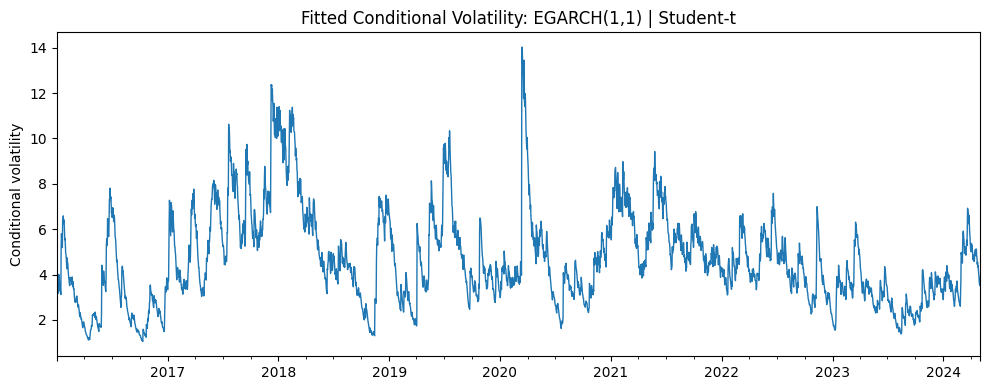

Saved: output\figures\conditional_volatility_best_bic.png


In [13]:
successful_fit_summary = model_fit_summary.loc[
    model_fit_summary["convergence_success"] & model_fit_summary["BIC"].notna()
].sort_values("BIC")

best_fit_id = None
figure_paths = []

if successful_fit_summary.empty:
    print("No successfully converged models available for conditional volatility plots.")
else:
    best_fit_id = successful_fit_summary.iloc[0]["fit_id"]
    best_result = fitted_models[best_fit_id]
    best_cond_vol = get_conditional_volatility(best_result)

    best_vol_path = OUTPUT_FIGURES_DIR / "conditional_volatility_best_bic.png"
    figure_paths.append(best_vol_path)

    fig, ax = plt.subplots(figsize=(10, 4))
    best_cond_vol.plot(ax=ax, linewidth=1.0)
    ax.set_title(f"Fitted Conditional Volatility: {best_fit_id}")
    ax.set_ylabel("Conditional volatility")
    ax.set_xlabel("")
    fig.tight_layout()
    fig.savefig(best_vol_path, dpi=300)
    plt.show()

    print(f"Saved: {best_vol_path.relative_to(PROJECT_ROOT)}")

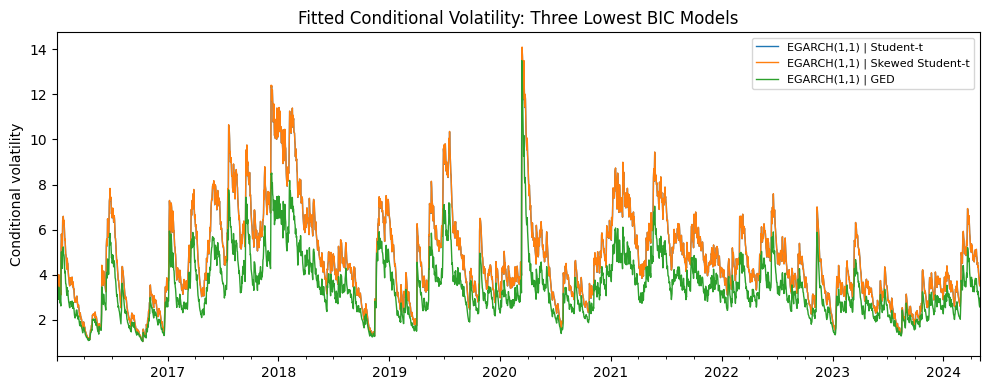

Saved: output\figures\conditional_volatility_top3_bic.png


In [14]:
if not successful_fit_summary.empty:
    top3 = successful_fit_summary.head(3)
    top3_vol_path = OUTPUT_FIGURES_DIR / "conditional_volatility_top3_bic.png"
    figure_paths.append(top3_vol_path)

    fig, ax = plt.subplots(figsize=(10, 4))
    for fit_id in top3["fit_id"]:
        get_conditional_volatility(fitted_models[fit_id]).plot(ax=ax, linewidth=1.0, label=fit_id)

    ax.set_title("Fitted Conditional Volatility: Three Lowest BIC Models")
    ax.set_ylabel("Conditional volatility")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(top3_vol_path, dpi=300)
    plt.show()

    print(f"Saved: {top3_vol_path.relative_to(PROJECT_ROOT)}")

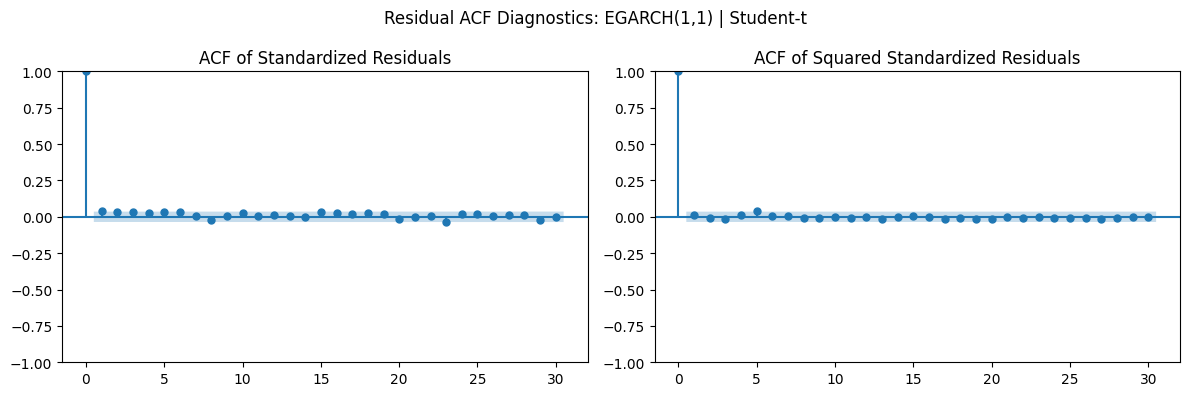

Saved: output\figures\acf_standardized_residuals_best_bic.png


In [15]:
if best_fit_id is not None:
    best_std_resid = get_standardized_residuals(fitted_models[best_fit_id])
    acf_path = OUTPUT_FIGURES_DIR / "acf_standardized_residuals_best_bic.png"
    figure_paths.append(acf_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(best_std_resid, lags=30, ax=axes[0])
    axes[0].set_title("ACF of Standardized Residuals")
    plot_acf(best_std_resid**2, lags=30, ax=axes[1])
    axes[1].set_title("ACF of Squared Standardized Residuals")
    fig.suptitle(f"Residual ACF Diagnostics: {best_fit_id}")
    fig.tight_layout()
    fig.savefig(acf_path, dpi=300)
    plt.show()

    print(f"Saved: {acf_path.relative_to(PROJECT_ROOT)}")

## 9. Files created and failed models

In [16]:
created_files = [
    MODEL_FIT_CSV,
    MODEL_FIT_TEX,
    RESIDUAL_DIAGNOSTICS_CSV,
    RESIDUAL_DIAGNOSTICS_TEX,
    *figure_paths,
]

created_files_table = pd.DataFrame(
    {"file": [str(path.relative_to(PROJECT_ROOT)) for path in created_files if path.exists()]}
)
display(created_files_table)

failed_models = model_fit_summary.loc[
    ~model_fit_summary["convergence_success"], ["fit_id", "convergence_flag", "error_message"]
]

if failed_models.empty:
    print("No model estimation failures were recorded.")
else:
    display(failed_models.reset_index(drop=True))

,file
0,output\tables\model_fit_summary.csv
1,output\tables\model_fit_summary.tex
2,output\tables\residual_diagnostics_summary.csv
3,output\tables\residual_diagnostics_summary.tex
4,output\figures\conditional_volatility_best_bic...
5,output\figures\conditional_volatility_top3_bic...
6,output\figures\acf_standardized_residuals_best...


No model estimation failures were recorded.


## 10. TODO for next notebook

- Use the reserved test sample for out-of-sample volatility forecasts.
- Compare forecast accuracy across ARCH-family models and innovation distributions.
- Decide on forecast loss functions and benchmark models.
- Consider AR or ARMA mean equations as robustness checks.